# 01 · Veri hazırlama ve kalite kontrolü

Bu notebook verinin **nereden geldiğini**, **nasıl küçültüldüğünü** ve **ne kadar güvenilir olduğunu** gösterir.
Analize geçmeden önce verinin kendisini sorgulamak, bir veri analistinin en önemli alışkanlığıdır.

## Veri kaynakları

| Veri | Kaynak | Dönem | Kullanım |
|---|---|---|---|
| Saatlik toplu taşıma yolculukları | İBB Açık Veri | Eki 2023 – Mar 2024 | Talep, abonman, otobüs yükü |
| İETT GTFS (hat, durak, sefer planı) | İBB Açık Veri | 2026 planı | Otobüsü ilçeye bağlama, sefer sayısı |
| Raylı sistem istasyonları | İBB Açık Veri | güncel | Erişim mesafesi |
| Saatlik trafik yoğunluğu | İBB Açık Veri | Eki 2023 – Mar 2024 | Zirve saat hızı |
| İlçe nüfusu (yaş kırılımlı) | İBB / TÜİK | 2023 | Çalışma çağı nüfusu |
| Sosyal yardım alan hane | İBB Açık Veri | 2023 | Fiyat duyarlılığı göstergesi |
| İlçe sınırları | OpenStreetMap | güncel | Harita, mekânsal eşleştirme |

## Veri hattı

```
src/download_external.py   küçük veri setlerini indirir
src/build_monthly.py       ~9 GB'lık aylık CSV'leri indirmeden okur, SQL ile
                           hafta içi 07:00-20:00'ye indirger -> parquet (~18 MB/ay)
src/build_reference.py     GTFS koordinat/karakter hatalarını düzeltir, durak ve
                           istasyonları ilçelere bağlar
sql/03..06                 ilçe ölçütlerini hesaplar (DuckDB)
```

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30, "display.width", 160)

from db import baglan, sorgu
from gorsel import *
stil_uygula()
con = baglan()

# İlçe kodlarını (ör. "EYUPSULTAN") grafiklerde düzgün Türkçe adla göstermek için
import geopandas as gpd
from utils import PROCESSED
ilceler = gpd.read_parquet(PROCESSED / "referans" / "ilceler.parquet")
AD = dict(zip(ilceler["ilce"], ilceler["ilce_adi"]))

## 1. Aylık veri hacmi
Her ay için kaç gün ve kaç yolcu var? Eksik ya da anormal bir ay var mı?

In [2]:
aylik = con.execute("""
    SELECT strftime(tarih, '%Y-%m')      AS ay,
           COUNT(DISTINCT tarih)         AS is_gunu,
           ROUND(SUM(yolcu_sayisi) / 1e6, 1) AS milyon_yolcu,
           ROUND(SUM(yolcu_sayisi) / COUNT(DISTINCT tarih) / 1e6, 2) AS gunluk_milyon
    FROM yolculuk
    GROUP BY 1 ORDER BY 1
""").df()
aylik

,ay,is_gunu,milyon_yolcu,gunluk_milyon
0,2023-10,22,153.5,6.98
1,2023-11,22,149.4,6.79
2,2023-12,21,145.3,6.92
3,2024-01,22,138.3,6.28
4,2024-02,21,141.0,6.71
5,2024-03,21,142.3,6.77


Hafta içi mesai saatlerinde (07–20) İstanbul'da günde yaklaşık **6,3–7 milyon** toplu taşıma binişi var.
Aylar arasında büyük bir sapma yok; Ocak'taki düşüş okulların yarıyıl tatiliyle (22 Ocak – 2 Şubat 2024) uyumlu.

## 2. Günlük seri: tatil ya da veri kesintisi var mı?

,tarih,milyon
84,2024-01-29,5.281796


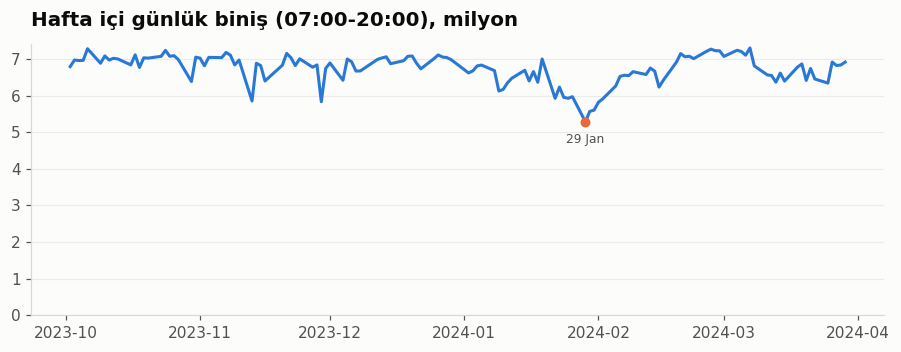

In [3]:
gunluk = con.execute("""
    SELECT tarih, SUM(yolcu_sayisi) / 1e6 AS milyon
    FROM yolculuk GROUP BY 1 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(gunluk["tarih"], gunluk["milyon"], color=MAVI)
ax.set_title("Hafta içi günlük biniş (07:00-20:00), milyon")
ax.set_ylim(0, None)
dusuk = gunluk[gunluk["milyon"] < gunluk["milyon"].median() * 0.8]
ax.scatter(dusuk["tarih"], dusuk["milyon"], color=TURUNCU, zorder=3, s=30)
for _, r in dusuk.iterrows():
    ax.annotate(r["tarih"].strftime("%d %b"), (r["tarih"], r["milyon"]),
                textcoords="offset points", xytext=(0, -14), ha="center", fontsize=8, color=YAZI_IKINCIL)
kaydet(fig, "01_gunluk_binis")
dusuk

Turuncu nokta medyanın %80'inin altındaki tek gün: **29 Ocak 2024**. O günün 13 saatinin tamamı veride mevcut,
yani bu bir **veri kesintisi değil**, genel bir talep düşüşü. Gün, yarıyıl tatili haftasına denk geliyor ve o haftanın tamamı düşük.
121 iş gününden biri olduğu için 6 aylık ortalamalara etkisi ihmal edilebilir.

## 3. Otobüs yolcularını ilçelere bağlama

Ham veride **normal otobüs** satırlarındaki ilçe alanı binişin yapıldığı yeri göstermiyor
(ör. 500T hattının yolcularının %95'i "Bakırköy" olarak kayıtlı). Bu yüzden her hattın
yolcularını, GTFS'teki duraklarının ilçelere dağılımına göre paylaştırıyoruz.
Raylı sistem, metrobüs ve deniz ulaşımında ise istasyonun ilçesi zaten doğru.

Aşağıdaki tablo bu eşleştirmenin **kapsamını** gösteriyor:

In [4]:
eslesme = sorgu(con, "03_ilce_yolculuk.sql")
eslesme

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,yol_turu,eslesen_yuzde,toplam_milyon_yolcu
0,OTOYOL,91.8,477.0
1,RAYLI,92.8,374.0
2,DENİZ,100.0,18.7


Yolcuların **%90'dan fazlası** bir ilçeye bağlanabiliyor. Eşleşmeyen kısım ağırlıklı olarak 2023-24'te çalışan ama
2026 sefer planında artık bulunmayan ya da kodu değişen otobüs hatları. Bu bir **sınırlama** olarak README'de yazılı.

## 4. Referans verilerin özeti

In [5]:
ref = PROCESSED / "referans"
ozet = pd.DataFrame({
    "kayıt": {
        "İETT durağı": len(pd.read_parquet(ref / "duraklar.parquet")),
        "Raylı sistem + metrobüs istasyonu": len(pd.read_parquet(ref / "istasyonlar.parquet")),
        "Otobüs hattı (GTFS, hafta içi)": pd.read_parquet(ref / "hat_saat_sefer.parquet")["hat_kodu"].nunique(),
        "İlçe": len(ilceler),
        "Trafik hücresi (~1 km²)": con.execute("SELECT COUNT(DISTINCT geohash) FROM trafik").fetchone()[0],
    }
})
ozet

,kayıt
İETT durağı,15386
Raylı sistem + metrobüs istasyonu,358
"Otobüs hattı (GTFS, hafta içi)",794
İlçe,39
Trafik hücresi (~1 km²),2459
